<a href="https://colab.research.google.com/github/Quy20061/Hoc_May/blob/main/Tuan4_BaiTap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BÀi 1


In [ ]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder
from sklearn.naive_bayes import CategoricalNB

# 1. Tạo tập dữ liệu từ bảng
data = {
    'Weather': ['Sunny', 'Sunny', 'Overcast', 'Rain', 'Rain', 'Rain', 'Overcast', 'Sunny', 'Sunny', 'Rain'],
    'Temp': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool', 'Cool', 'Cool', 'Mild', 'Cool', 'Mild'],
    'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'Normal'],
    'Windy': ['False', 'True', 'False', 'False', 'False', 'True', 'True', 'False', 'False', 'False'],
    'Play': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes']
}

df = pd.DataFrame(data)

# Tách đặc trưng (features) và nhãn (target)
X = df[['Weather', 'Temp', 'Humidity', 'Windy']]
y = df['Play']

# 2. Mã hóa dữ liệu dạng chữ (Categorical) sang dạng số
encoder = OrdinalEncoder()
X_encoded = encoder.fit_transform(X)

# 3. Khởi tạo mô hình Naive Bayes (tắt Laplace smoothing để khớp 100% với tính toán tay)
# Nếu muốn dùng Laplace smoothing mặc định, hãy để alpha=1.0
model = CategoricalNB(alpha=1e-10)
model.fit(X_encoded, y)

# 4. Dự đoán cho mẫu X_test = (Sunny, Cool, High, True)
sample = pd.DataFrame([['Sunny', 'Cool', 'High', 'True']], columns=['Weather', 'Temp', 'Humidity', 'Windy'])
sample_encoded = encoder.transform(sample)

prediction = model.predict(sample_encoded)
probabilities = model.predict_proba(sample_encoded)

# 5. In kết quả
print(f"Dự đoán cho mẫu {sample.values[0].tolist()}: {prediction[0]}")
print(f"Xác suất theo các lớp {model.classes_}: {probabilities[0]}")

Dự đoán cho mẫu ['Sunny', 'Cool', 'High', 'True']: No
Xác suất theo các lớp ['No' 'Yes']: [0.91011236 0.08988764]


# Bài 2

In [ ]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder
from sklearn.naive_bayes import CategoricalNB

# 1. Khởi tạo tập dữ liệu 15 mẫu
data = {
    'Age': ['youth', 'youth', 'middle', 'senior', 'senior', 'senior', 'middle', 'youth', 'youth', 'senior', 'middle', 'youth', 'middle', 'senior', 'youth'],
    'Income': ['high', 'high', 'high', 'medium', 'low', 'low', 'low', 'medium', 'low', 'medium', 'medium', 'medium', 'high', 'medium', 'low'],
    'Student': ['no', 'no', 'no', 'no', 'yes', 'yes', 'yes', 'no', 'yes', 'yes', 'no', 'yes', 'yes', 'no', 'no'],
    'Credit': ['fair', 'fair', 'fair', 'fair', 'fair', 'excellent', 'excellent', 'fair', 'fair', 'fair', 'excellent', 'excellent', 'fair', 'excellent', 'fair'], # chú ý ID 2 credit là excellent theo đúng bảng
    'BuyLaptop': ['no', 'no', 'yes', 'yes', 'yes', 'no', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'no', 'no']
}

# Cập nhật chuẩn xác từng dòng theo bảng dữ liệu:
data['Credit'][1] = 'excellent'

df = pd.DataFrame(data)

# Tách đặc trưng và nhãn
X = df[['Age', 'Income', 'Student', 'Credit']]
y = df['BuyLaptop']

# 2. Mã hóa dữ liệu dạng chuỗi sang số
encoder = OrdinalEncoder()
X_encoded = encoder.fit_transform(X)

# 3. Huấn luyện mô hình Naive Bayes (alpha=1e-10 để khớp với xác suất tính tay không làm mịn)
model = CategoricalNB(alpha=1e-10)
model.fit(X_encoded, y)

# 4. Dự đoán cho mẫu X = (youth, medium, yes, fair)
sample_data = [['youth', 'medium', 'yes', 'fair']]
sample = pd.DataFrame(sample_data, columns=['Age', 'Income', 'Student', 'Credit'])
sample_encoded = encoder.transform(sample)

prediction = model.predict(sample_encoded)[0]
probabilities = model.predict_proba(sample_encoded)[0]

# 5. In kết quả và phần kết luận
print("=" * 45)
print("KẾT QUẢ PHÂN LỚP NAIVE BAYES")
print("=" * 45)
print(f"Mẫu kiểm tra X: {dict(zip(sample.columns, sample_data[0]))}\n")

print("Xác suất tiên nghiệm và hậu nghiệm:")
prob_dict = dict(zip(model.classes_, probabilities))
for cls, prob in prob_dict.items():
    print(f" - P(BuyLaptop = '{cls}' | X) = {prob:.4f} ({prob * 100:.2f}%)")

print("\n" + "-" * 45)
print("KẾT LUẬN:")
if prob_dict['yes'] > prob_dict['no']:
    print(f"Do P(yes | X) ({prob_dict['yes']:.4f}) > P(no | X) ({prob_dict['no']:.4f}),")
    print("=> BuyLaptop = 'yes'")
else:
    print(f"Do P(no | X) ({prob_dict['no']:.4f}) > P(yes | X) ({prob_dict['yes']:.4f}),")
    print("=> BuyLaptop = 'no'")
print("=" * 45)

KẾT QUẢ PHÂN LỚP NAIVE BAYES
Mẫu kiểm tra X: {'Age': 'youth', 'Income': 'medium', 'Student': 'yes', 'Credit': 'fair'}

Xác suất tiên nghiệm và hậu nghiệm:
 - P(BuyLaptop = 'no' | X) = 0.0708 (7.08%)
 - P(BuyLaptop = 'yes' | X) = 0.9292 (92.92%)

---------------------------------------------
KẾT LUẬN:
Do P(yes | X) (0.9292) > P(no | X) (0.0708),
=> BuyLaptop = 'yes'


# BÀI 3

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(5572, 2)
Category    object
Message     object
dtype: object
Category    0
Message     0
dtype: int64
Trùng lặp: 415
Category
ham     4825
spam     747
Name: count, dtype: int64
Category
ham     0.866
spam    0.134
Name: proportion, dtype: float64
          n_char  n_word
Category                
ham         71.4    14.3
spam       138.0    23.8
            n_char       n_word
count  5572.000000  5572.000000
mean     80.368988    15.584171
std      59.926946    11.406598
min       2.000000     1.000000
25%      35.750000     7.000000
50%      61.000000    12.000000
75%     122.000000    23.000000
max     910.000000   171.000000


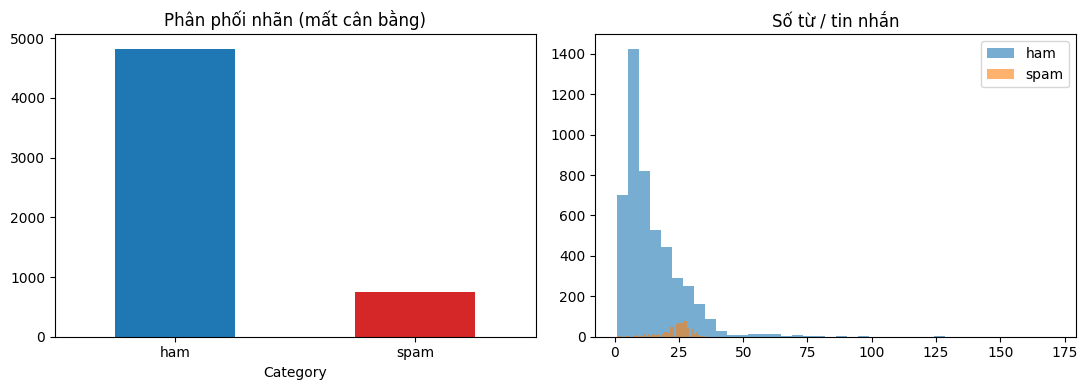

Kích thước từ vựng: 6654

== BoW + MultinomialNB | F1(spam) = 0.9379
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.96      0.91      0.94       149

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115


== BoW + LogisticRegression | F1(spam) = 0.9329
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       966
        spam       0.99      0.89      0.93       149

    accuracy                           0.98      1115
   macro avg       0.98      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115


===== BẢNG SO SÁNH =====
 Vectorizer               Model  Accuracy  Precision  Recall     F1  CV_F1
       BoW         Naive Bayes    0.9839     0.9645  0.9128 0.9379 0.9333
       BoW Logistic Regression    0.9839     0.9925  

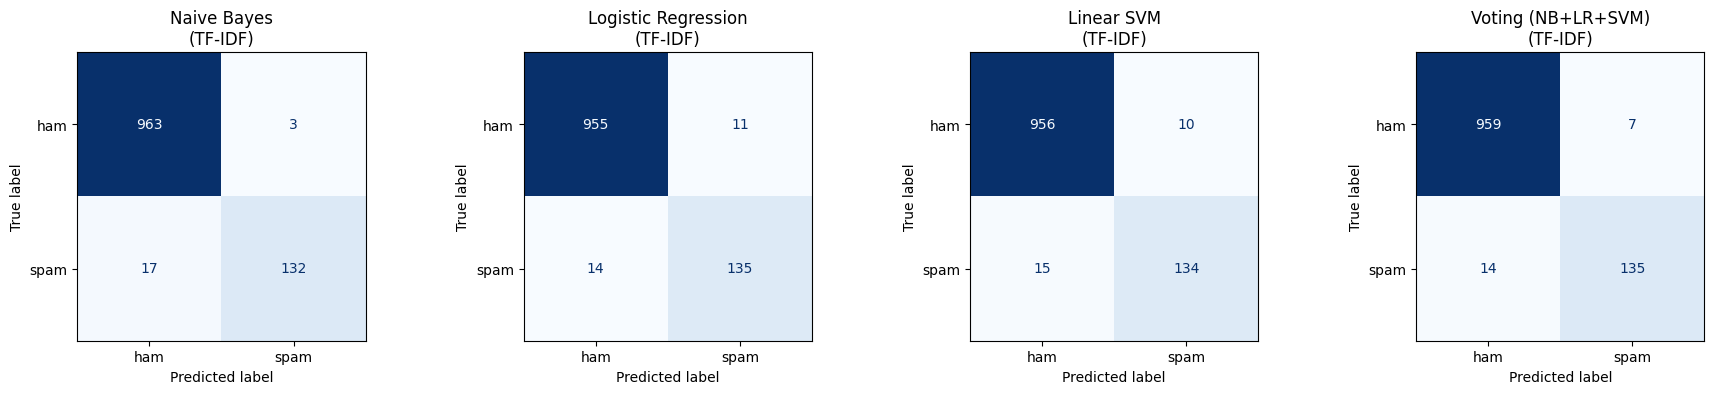


### ('TF-IDF', 'Naive Bayes') | Confusion matrix [[TN, FP], [FN, TP]]: [[963, 3], [17, 132]]
              precision    recall  f1-score   support

         ham     0.9827    0.9969    0.9897       966
        spam     0.9778    0.8859    0.9296       149

    accuracy                         0.9821      1115
   macro avg     0.9802    0.9414    0.9596      1115
weighted avg     0.9820    0.9821    0.9817      1115


### ('TF-IDF', 'Logistic Regression') | Confusion matrix [[TN, FP], [FN, TP]]: [[955, 11], [14, 135]]
              precision    recall  f1-score   support

         ham     0.9856    0.9886    0.9871       966
        spam     0.9247    0.9060    0.9153       149

    accuracy                         0.9776      1115
   macro avg     0.9551    0.9473    0.9512      1115
weighted avg     0.9774    0.9776    0.9775      1115


### ('TF-IDF', 'Linear SVM') | Confusion matrix [[TN, FP], [FN, TP]]: [[956, 10], [15, 134]]
              precision    recall  f1-score   support



In [ ]:
import re, os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score
# --- import bổ sung cho phần 4-7 ---
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.ensemble import VotingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             accuracy_score, precision_score, recall_score)

try:
    from google.colab import drive
    drive.mount('/content/drive')
    PATH = '/content/drive/MyDrive/Học máy/mail_data.csv'   # sửa nếu thư mục khác
except ImportError:
    PATH = 'mail_data.csv'                                    # chạy local
df = pd.read_csv(PATH, encoding='utf-8')

# ---------- 1. Khám phá dữ liệu ----------
print(df.shape); print(df.dtypes); print(df.isna().sum())
print('Trùng lặp:', df.duplicated().sum())
print(df['Category'].value_counts()); print(df['Category'].value_counts(normalize=True).round(3))
df['n_char'] = df['Message'].str.len()
df['n_word'] = df['Message'].str.split().str.len()
print(df.groupby('Category')[['n_char', 'n_word']].mean().round(1))
print(df[['n_char', 'n_word']].describe())

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
df['Category'].value_counts().plot.bar(ax=ax[0], color=['tab:blue', 'tab:red'], rot=0)
ax[0].set_title('Phân phối nhãn (mất cân bằng)')
for c in df['Category'].unique():
    ax[1].hist(df.loc[df.Category == c, 'n_word'], bins=40, alpha=.6, label=c)
ax[1].set_title('Số từ / tin nhắn'); ax[1].legend()
plt.tight_layout(); plt.savefig('eda.png', dpi=120); plt.show()

# ---------- 2. Tiền xử lý ----------
SLANG = {'u': 'you', 'ur': 'your', 'r': 'are', 'im': 'i am', 'dun': 'do not',
         'txt': 'text', '2': 'to', '4': 'for', 'pls': 'please', 'wif': 'with'}  # có thể bổ sung
def clean(t):
    t = t.lower()
    t = re.sub(r'[^a-z\s]', ' ', t)          # bỏ số, dấu câu, ký tự đặc biệt
    t = ' '.join(SLANG.get(w, w) for w in t.split())   # chuẩn hoá slang + bỏ khoảng trắng thừa
    return t
# Lưu ý: nếu bỏ chữ số thì mất thông tin "số điện thoại / giá tiền" vốn là dấu hiệu spam mạnh
# -> có thể thử thêm biến thể thay số bằng token 'NUM' và so sánh.
df['clean'] = df['Message'].apply(clean)
df['y'] = (df['Category'] == 'spam').astype(int)

# ---------- 3. Vector hoá: Bag-of-Words ----------
X_tr, X_te, y_tr, y_te = train_test_split(df['clean'], df['y'], test_size=.2,
                                          stratify=df['y'], random_state=42)
bow = CountVectorizer(stop_words='english', min_df=2, ngram_range=(1, 2))
Xtr, Xte = bow.fit_transform(X_tr), bow.transform(X_te)    # fit CHỈ trên tập train
print('Kích thước từ vựng:', len(bow.vocabulary_))

for name, m in [('MultinomialNB', MultinomialNB()),
                ('LogisticRegression', LogisticRegression(max_iter=1000, class_weight='balanced'))]:
    m.fit(Xtr, y_tr); p = m.predict(Xte)
    print(f'\n== BoW + {name} | F1(spam) = {f1_score(y_te, p):.4f}')
    print(classification_report(y_te, p, target_names=['ham', 'spam']))

# ---------- 4. Huấn luyện 3 mô hình x 2 cách vector hoá (BoW, TF-IDF) ----------
vecs = {'BoW':    lambda: CountVectorizer(stop_words='english', min_df=2, ngram_range=(1, 2)),
        'TF-IDF': lambda: TfidfVectorizer(stop_words='english', min_df=2, ngram_range=(1, 2), sublinear_tf=True)}
models = {'Naive Bayes':         lambda: MultinomialNB(alpha=0.1),
          'Logistic Regression': lambda: LogisticRegression(max_iter=1000, class_weight='balanced', C=10),
          'Linear SVM':          lambda: LinearSVC(class_weight='balanced', C=1)}
skf = StratifiedKFold(5, shuffle=True, random_state=42)

rows, fitted = [], {}
for v, vf in vecs.items():
    for m, mf in models.items():
        pipe = make_pipeline(vf(), mf()).fit(X_tr, y_tr); p = pipe.predict(X_te)
        cv = cross_val_score(make_pipeline(vf(), mf()), X_tr, y_tr, cv=skf, scoring='f1').mean()
        rows.append(dict(Vectorizer=v, Model=m, Accuracy=accuracy_score(y_te, p),
                         Precision=precision_score(y_te, p), Recall=recall_score(y_te, p),
                         F1=f1_score(y_te, p), CV_F1=cv))
        fitted[(v, m)] = pipe

# ---------- 5. Kết hợp 3 mô hình (hard voting) trên TF-IDF ----------
best_v = 'TF-IDF'
mk_vote = lambda: make_pipeline(vecs[best_v](),
          VotingClassifier([(k[:2], mf()) for k, mf in models.items()], voting='hard'))
vote = mk_vote().fit(X_tr, y_tr); p = vote.predict(X_te)
cv = cross_val_score(mk_vote(), X_tr, y_tr, cv=skf, scoring='f1').mean()
rows.append(dict(Vectorizer=best_v, Model='Voting (NB+LR+SVM)', Accuracy=accuracy_score(y_te, p),
                 Precision=precision_score(y_te, p), Recall=recall_score(y_te, p),
                 F1=f1_score(y_te, p), CV_F1=cv))
fitted[(best_v, 'Voting (NB+LR+SVM)')] = vote
res = pd.DataFrame(rows).round(4); res.to_csv('results.csv', index=False)
print('\n===== BẢNG SO SÁNH =====\n', res.to_string(index=False))

# ---------- 6. Confusion matrix ----------
show = [(best_v, m) for m in ['Naive Bayes', 'Logistic Regression', 'Linear SVM', 'Voting (NB+LR+SVM)']]
fig, axs = plt.subplots(1, 4, figsize=(18, 4))
for ax, k in zip(axs, show):
    pr = fitted[k].predict(X_te)
    ConfusionMatrixDisplay(confusion_matrix(y_te, pr), display_labels=['ham', 'spam']).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{k[1]}\n({k[0]})')
plt.tight_layout(); plt.savefig('confusion_matrices.png', dpi=130); plt.show()

# ---------- 7. Báo cáo chi tiết ----------
for k in show:
    pr = fitted[k].predict(X_te)
    print('\n###', k, '| Confusion matrix [[TN, FP], [FN, TP]]:', confusion_matrix(y_te, pr).tolist())
    print(classification_report(y_te, pr, target_names=['ham', 'spam'], digits=4))

# ---------- 8. Phân tích lỗi của Naive Bayes ----------
pr = fitted[(best_v, 'Naive Bayes')].predict(X_te); wrong = X_te.index[pr != y_te]
print('\nNaive Bayes sai', len(wrong), 'mẫu:')
print(pd.DataFrame({'true': y_te[wrong], 'pred': pr[pr != y_te],
                    'Message': df.loc[wrong, 'Message'].str[:100]}).head(10).to_string())